# Correlation with Tokyo Weather

## Dataset

Source: Meteostat Hourly API

Location: Tokyo Station area (≈ 35.6812, 139.7671) — timezone Asia/Tokyo

Cadence: Hourly (uniform sampling)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Hourly


plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## Data

In [22]:
TOKYO = Point(35.6812, 139.7671)
START = datetime(2024, 1, 1)
END = datetime(2024, 3, 31)

df = Hourly(TOKYO, START, END).fetch()

if df.index.tz is None:
    df = df.tz_localize('UTC').tz_convert('Asia/Tokyo')
else:
    df = df.tz_convert('Asia/Tokyo')

df = df[["temp","rhum","wspd"]]

df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('1h')

df.head()

,temp,rhum,wspd
time,,,
2024-01-01 09:00:00+09:00,9.7,46.0,20.5
2024-01-01 10:00:00+09:00,10.6,40.0,29.5
2024-01-01 11:00:00+09:00,11.5,41.0,20.5
2024-01-01 12:00:00+09:00,11.6,37.0,18.4
2024-01-01 13:00:00+09:00,11.8,34.0,20.5


## Helpers

In [23]:
def xcorr(a: pd.Series, b: pd.Series, max_lag_hours: int = 72) -> pd.Series:
    joined = pd.concat([a, b], axis=1).dropna()
    if joined.empty or len(joined) < 24:
        raise ValueError("Not enough overlapping data to compute correlation.")
    x = (joined.iloc[:,0] - joined.iloc[:,0].mean()) / joined.iloc[:,0].std()
    y = (joined.iloc[:,1] - joined.iloc[:,1].mean()) / joined.iloc[:,1].std()
    lags = np.arange(-max_lag_hours, max_lag_hours + 1, dtype=int)
    vals = []
    for L in lags:
        if L < 0:
            vals.append(np.corrcoef(x[-L:], y[:len(y)+L])[0,1])
        elif L > 0:
            vals.append(np.corrcoef(x[:len(x)-L], y[L:])[0,1])
        else:
            vals.append(np.corrcoef(x, y)[0,1])
    return pd.Series(vals, index=lags)

In [24]:
def znorm(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

In [25]:
def near_zero_peak(s: pd.Series, w: int = 6):
    win = s.loc[-w:w]
    lag = int(win.abs().idxmax())
    r   = float(win.loc[lag])
    return lag, r

## Day 4

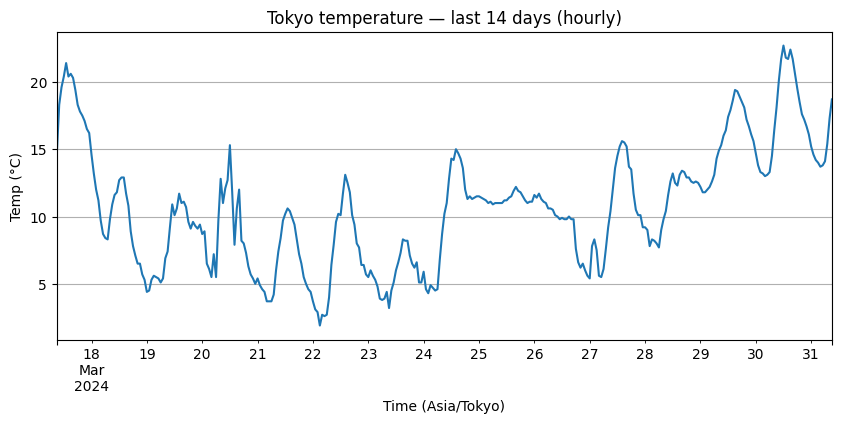

In [26]:
start_date = df.index.max() - pd.Timedelta('14D')
ax = df.loc[df.index >= start_date, 'temp'].plot(title="Tokyo temperature — last 14 days (hourly)")

ax.set_xlabel("Time (Asia/Tokyo)")
ax.set_ylabel("Temp (°C)")
plt.show()

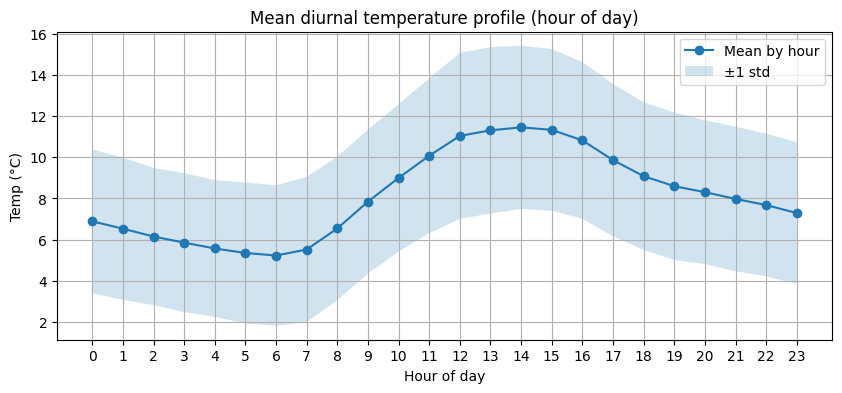

In [27]:
hourly_stats = df['temp'].groupby(df.index.hour).agg(['mean','std'])
hrs = np.arange(24)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(hrs, hourly_stats['mean'], marker='o', label='Mean by hour')
ax.fill_between(hrs,
                hourly_stats['mean'] - hourly_stats['std'],
                hourly_stats['mean'] + hourly_stats['std'],
                alpha=0.2, label='±1 std')
ax.set_xticks(hrs)
ax.set_title("Mean diurnal temperature profile (hour of day)")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Temp (°C)")
ax.legend()
plt.show()

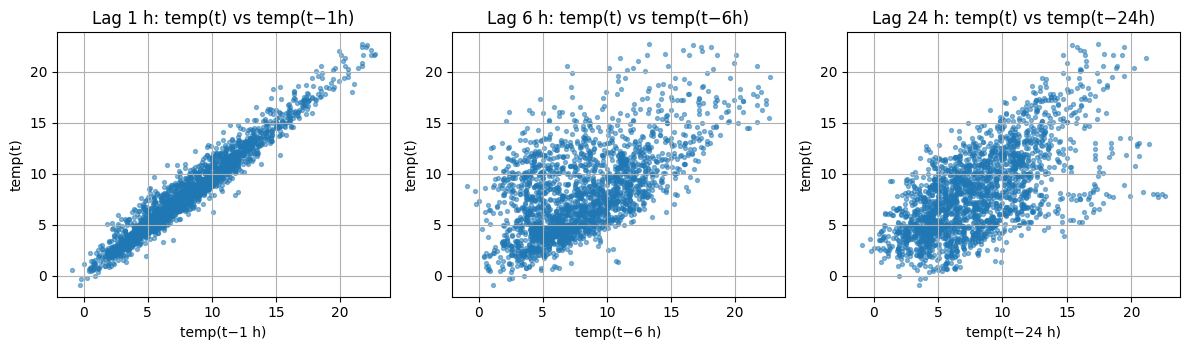

In [28]:
lags = [1, 6, 24]
cols = 3
fig, axes = plt.subplots(1, cols, figsize=(12, 3.6))
for i, L in enumerate(lags):
    ax = axes[i]
    s = df['temp'].dropna()
    aligned = pd.concat([s.shift(L).rename(f"temp(t-{L}h)"), s.rename("temp(t)")], axis=1).dropna()
    ax.scatter(aligned.iloc[:,0], aligned.iloc[:,1], s=8, alpha=0.5)
    ax.set_title(f"Lag {L} h: temp(t) vs temp(t−{L}h)")
    ax.set_xlabel(f"temp(t−{L} h)"); ax.set_ylabel("temp(t)")
plt.tight_layout()
plt.show()

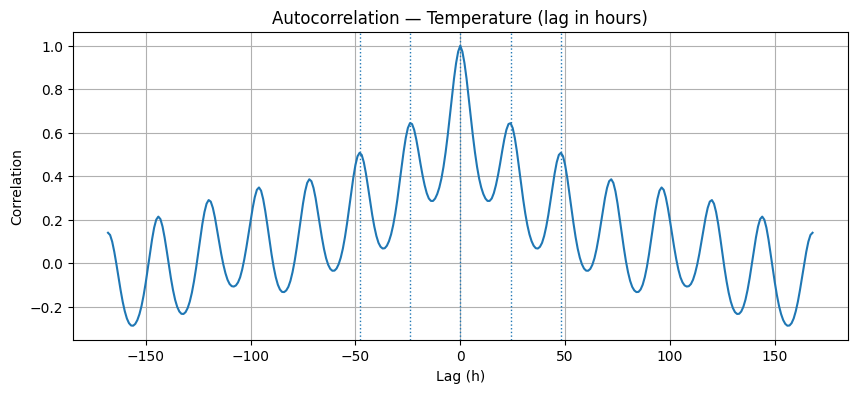

In [29]:
acf_temp = xcorr(df['temp'], df['temp'], max_lag_hours=168)
ax = acf_temp.plot(title="Autocorrelation — Temperature (lag in hours)")
ax.set_xlabel("Lag (h)"); ax.set_ylabel("Correlation")
for k in (-48, -24, 0, 24, 48):
    ax.axvline(k, linestyle=':', linewidth=1)
plt.show()

In [30]:
deadband = 6   # ignore |lag| <= 6 h for "repeating" peaks
win24    = 3   # search window around 24 h (±3 h)

lags = acf_temp.index.values
acf_db = acf_temp.copy()
mask_dead = (lags >= -deadband) & (lags <= deadband)
acf_db.loc[mask_dead] = np.nan

# Global repeating peak (excluding near-zero band)
if acf_db.dropna().empty:
    g_lag = None; g_val = None
else:
    g_lag = int(acf_db.abs().idxmax())
    g_val = float(acf_db.loc[g_lag])

# Peak near ±24 h (if present)
mask24 = (np.abs(np.abs(lags) - 24) <= win24)
acf_24 = acf_db.loc[mask24]
if acf_24.dropna().empty:
    lag_24 = None; val_24 = None
else:
    lag_24 = int(acf_24.abs().idxmax())
    val_24 = float(acf_24.loc[lag_24])

print("Daily ACF summary (robust):")
print(f"  Ignored deadband around 0 h: ±{deadband} h")
print(f"  Global repeating peak (|lag|>{deadband} h): lag={g_lag} h, r={g_val:.2f}" if g_lag is not None else
      "  Global repeating peak: not found (insufficient lags)")
print(f"  Peak near ±24 h (±{win24} h window): lag={lag_24} h, r={val_24:.2f}" if lag_24 is not None else
      "  Peak near ±24 h: not found")

Daily ACF summary (robust):
  Ignored deadband around 0 h: ±6 h
  Global repeating peak (|lag|>6 h): lag=24 h, r=0.64
  Peak near ±24 h (±3 h window): lag=24 h, r=0.64


## Day 5

### Signal & context: Hourly temperature in Tokyo, Japan (Meteostat).

### Use case (WHAT):
Understand recurring daily temperature patterns in Tokyo well enough to support simple, near‑term planning (e.g., comfort, ventilation timing, sea‑breeze awareness) and to set up fair comparisons with other signals in later days.

### Problem statement:
The temperature series contains repeating daily patterns but also day‑to‑day variability.

We need a concise description of that repeat so we can:
- summarize what a “typical day” looks like,
- recognize when a given day deviates from the usual pattern

### Objectives (WHAT to deliver):

Confirm and describe the daily repetition (period and strength) using autocorrelation and simple visuals (done in Day 4).

State a practical target window for interpreting short‑term timing (same‑day effects within ±6 h), distinct from the repeat‑day signal near ±24 h.

Define clear reporting metrics for later days: sign of relationship, peak lag (h), and a one‑sentence, plain‑English interpretation tied to the use case.

### WHY this matters:

A stable daily rhythm means correlation methods will find large peaks near ±24 h; without an explicit use case, those can be misread as causal leads/lags.

By declaring the same‑day window (±6 h) up front, we ensure that later results focus on actionable timing (who moves first within a few hours) rather than on day‑to‑day repetition.

## Day 6

In [35]:
pairs = [("Temp ↔ Humidity", 'temp', 'rhum'),
         ("Temp ↔ Wind",     'temp', 'wspd')]

rows_global, rows_local = [], []
series_for_plots = {}

for name, a, b in pairs:
    s = xcorr(df[a], df[b], max_lag_hours=72)  # z‑norm is inside xcorr
    series_for_plots[name] = s

    # Global peak (often day‑to‑day repetition)
    g_lag = int(s.abs().idxmax())
    g_r   = float(s.loc[g_lag])
    g_sign = "positive" if g_r >= 0 else "negative"
    g_text = (
        f"{b} lags {a} by {g_lag} h (temp leads)" if g_lag > 0 else
        f"{b} leads {a} by {abs(g_lag)} h" if g_lag < 0 else
        "move together (0 h lag)"
    )
    rows_global.append((name, g_sign, g_lag, g_r, g_text))

    # Same‑day (±6 h)
    l_lag, l_r = near_zero_peak(s, 6)
    l_sign = "positive" if l_r >= 0 else "negative"
    l_text = (
        f"{b} lags {a} by {l_lag} h (same‑day)" if l_lag > 0 else
        f"{b} leads {a} by {abs(l_lag)} h (same‑day)" if l_lag < 0 else
        "move together (0 h, same‑day)"
    )
    rows_local.append((name + " (±6 h)", l_sign, l_lag, l_r, l_text))

summary_global = pd.DataFrame(rows_global, columns=["Pair","Sign","Peak lag (h)","Correlation","Interpretation"])
summary_local  = pd.DataFrame(rows_local,  columns=["Pair","Sign","Peak lag (h)","Correlation","Interpretation"])

In [36]:
summary_global

,Pair,Sign,Peak lag (h),Correlation,Interpretation
0,Temp ↔ Humidity,positive,-14,0.282990,rhum leads temp by 14 h
1,Temp ↔ Wind,positive,25,0.249694,wspd lags temp by 25 h (temp leads)


In [37]:
summary_local

,Pair,Sign,Peak lag (h),Correlation,Interpretation
0,Temp ↔ Humidity (±6 h),negative,0,-0.132041,"move together (0 h, same‑day)"
1,Temp ↔ Wind (±6 h),positive,1,0.201061,wspd lags temp by 1 h (same‑day)


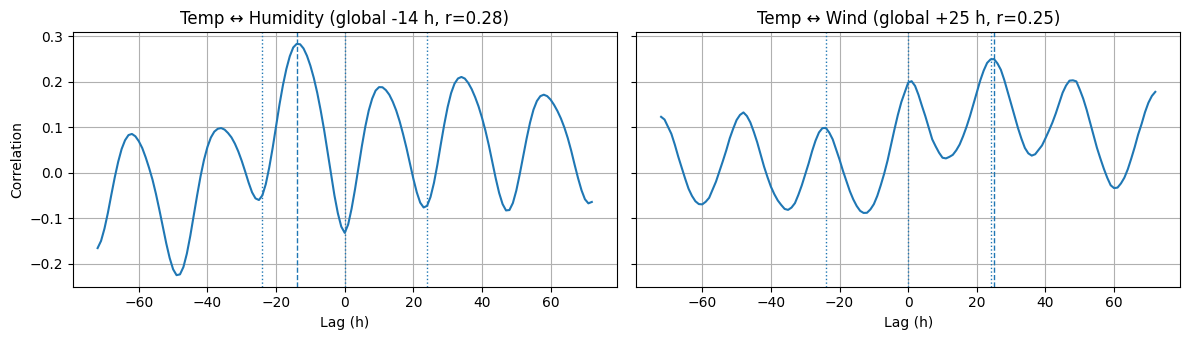

In [38]:
n = len(series_for_plots)
if n:
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3.5*rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (name, s) in enumerate(series_for_plots.items()):
        ax = axes[i]
        s.plot(ax=ax)
        for k in (-24, 0, 24):
            ax.axvline(k, linestyle=':', linewidth=1)
        g_lag = s.abs().idxmax()
        ax.axvline(g_lag, linestyle='--', linewidth=1)
        ax.set_title(f"{name} (global {g_lag:+} h, r={s.loc[g_lag]:.2f})")
        ax.set_xlabel("Lag (h)"); ax.set_ylabel("Correlation")

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

### Day 7